In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec


import os

import seaborn as sns



# Load data

In [2]:
# Load barcode dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [116]:
# Load fragments file
frag_in_housekeeping_file = os.path.join(Union_cell_subdir, 'frag_in_housekeeping.bed')
frag_in_housekeeping = pd.read_csv(frag_in_housekeeping_file, sep='\t', index_col=3, header=None)
frag_in_housekeeping.index.name = 'atac_BC'
frag_in_housekeeping.columns = ['chrom', 'start', 'end', 'support', 'gene_chrom', 'gene_start', 'gene_end', 'gene_name', 'bp_overlap']
frag_in_housekeeping['atac_bc'] = frag_in_housekeeping.index.map(lambda x: x.split('-1')[0])
frag_in_housekeeping['frag_length'] = frag_in_housekeeping['end'] - frag_in_housekeeping['start']



In [19]:
frag_in_housekeeping.head(2)

,chrom,start,end,support,gene_chrom,gene_start,gene_end,gene_name,bp_overlap,atac_bc,frag_length
atac_BC,,,,,,,,,,,
GATTGCTGTGCGGTTC-1,chr1,1785095,1785410,1,chr1,1785285,1891117,GNB1,125,GATTGCTGTGCGGTTC,315
GCTTCATCATATGGTG-1,chr1,1785349,1785670,1,chr1,1785285,1891117,GNB1,321,GCTTCATCATATGGTG,321


In [71]:
bc_by_gene_frag_counts = frag_in_housekeeping.groupby(['atac_bc', 'gene_name']).size().unstack(fill_value=0)
union_cell_info['sufficient_HKG_frag'] = union_cell_info.index.map((bc_by_gene_frag_counts >= 3).sum(axis=1) >= 1).fillna(False) # at least 2 housekeeping genes with at least 2 fragments each

In [117]:
total_frag_in_housekeeping = frag_in_housekeeping.groupby('atac_bc').size()
union_cell_info['total_frag_in_housekeeping'] = union_cell_info.index.map(total_frag_in_housekeeping).fillna(0).astype(int)

union_cell_info['HKG_frag_percent'] = union_cell_info['total_frag_in_housekeeping'] / union_cell_info['total_fragments']
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,total_frag_in_housekeeping,not_enough_HKG_frag,sufficient_HKG_frag,HKG_frag_percent,clusters_peakvi_TSSpeaks_unionBC
atac_bc,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,10,False,True,0.004146,1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,9,True,False,0.000997,5


Text(0, 0.5, 'log1p(total_frag_in_housekeeping)')

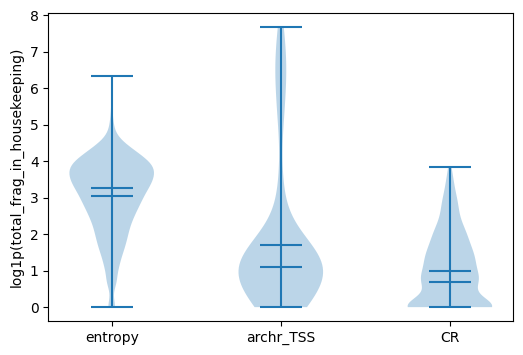

In [78]:
fig, ax = plt.subplots(figsize=(6, 4))

housekeeping_total_frag = [np.log1p(union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'total_frag_in_housekeeping']), 
                           np.log1p(union_cell_info.loc[~union_cell_info['atac_pass_archr_TSS'], 'total_frag_in_housekeeping']), 
                           np.log1p(union_cell_info.loc[~union_cell_info['atac_pass_CR'], 'total_frag_in_housekeeping'])]

_ = ax.violinplot(housekeeping_total_frag, 
                  positions=[1, 2, 3], 
                  showmeans=True, showmedians=True)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['entropy', 'archr_TSS', 'CR'])
ax.set_ylabel('log1p(total_frag_in_housekeeping)')

Text(0, 0.5, 'HKG_frag_percent')

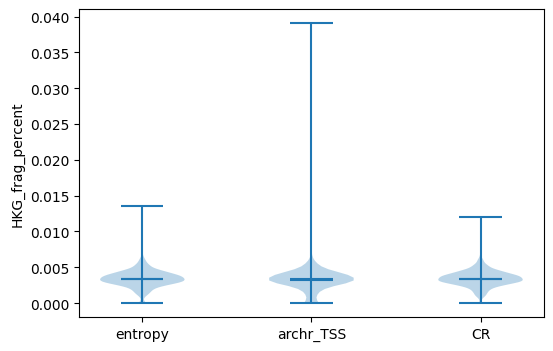

In [119]:
fig, ax = plt.subplots(figsize=(6, 4))

housekeeping_total_frag = [union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'HKG_frag_percent'], 
                           union_cell_info.loc[union_cell_info['atac_pass_archr_TSS'], 'HKG_frag_percent'], 
                           union_cell_info.loc[union_cell_info['atac_pass_CR'], 'HKG_frag_percent']]

_ = ax.violinplot(housekeeping_total_frag, 
                  positions=[1, 2, 3], 
                  showmeans=True, showmedians=True)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['entropy', 'archr_TSS', 'CR'])
ax.set_ylabel('HKG_frag_percent')



Text(0, 0.5, 'HKG_frag_percent')

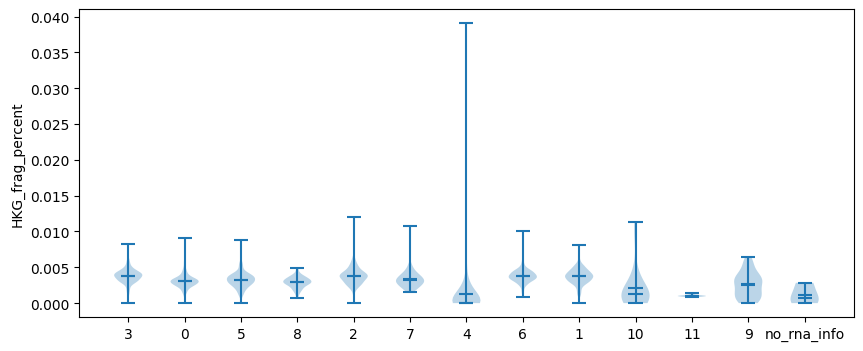

In [96]:
fig, ax = plt.subplots(figsize=(10, 4))

RNA_clusters = union_cell_info['leiden_RNA_scVI'].unique()

housekeeping_total_frag = [union_cell_info.loc[union_cell_info['leiden_RNA_scVI'] == cluster, 'HKG_frag_percent'] for cluster in RNA_clusters]

x_pos = np.arange(len(RNA_clusters) )
_ = ax.violinplot(housekeeping_total_frag, 
                  positions=x_pos,
                  showmeans=True, showmedians=True)
ax.set_xticks(x_pos)
ax.set_xticklabels(RNA_clusters)
ax.set_ylabel('HKG_frag_percent')


In [99]:
reasonable_RNA_clusters = ['0', '1', '2', '3',  '5', '6', '7', '8']

union_cell_info.loc[union_cell_info['leiden_RNA_scVI'].isin(reasonable_RNA_clusters), 'HKG_frag_percent'].describe()   

count    2035.000000
mean        0.003485
std         0.001146
min         0.000000
25%         0.002810
50%         0.003431
75%         0.004095
max         0.012090
Name: HKG_frag_percent, dtype: float64

In [103]:
union_cell_info['sufficient_HKG_frag'] = union_cell_info['HKG_frag_percent'] > 0.002
union_cell_info.groupby(['atac_pass_entropy', 'sufficient_HKG_frag']).size().unstack(fill_value=0)

sufficient_HKG_frag,False,True
atac_pass_entropy,,
False,220,63
True,215,1886


In [104]:
union_cell_info.groupby(['atac_pass_archr_TSS', 'sufficient_HKG_frag']).size().unstack(fill_value=0)

sufficient_HKG_frag,False,True
atac_pass_archr_TSS,,
False,135,117
True,300,1832


In [105]:
union_cell_info.groupby(['atac_pass_CR', 'sufficient_HKG_frag']).size().unstack(fill_value=0)

sufficient_HKG_frag,False,True
atac_pass_CR,,
False,255,170
True,180,1779
